 # Setup

In [16]:
PASCODE_PATH = ".."

import sys
sys.path.append(PASCODE_PATH) # NOTE
import PASCode
PASCode.random_seed.set_seed(0)

import scanpy as sc
import numpy as np
import torch

DATA_PATH = '../data/' # NOTE

 # load data

In [17]:
file_path = DATA_PATH + 'synth_demo.h5ad'
adata = sc.read_h5ad(file_path)

 # load pre-trained model

In [18]:
model = PASCode.model.GAT(
    in_channels=adata.X.shape[1], out_channels=64, num_class=3, heads=4)
model.load_state_dict(torch.load('./trained_model.pt'))

<All keys matched successfully>

 # predict PAC scores

In [19]:
adata.obs['pac_score'] = model.predict(PASCode.Data().adata2gdata(adata))

 # visualize

/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


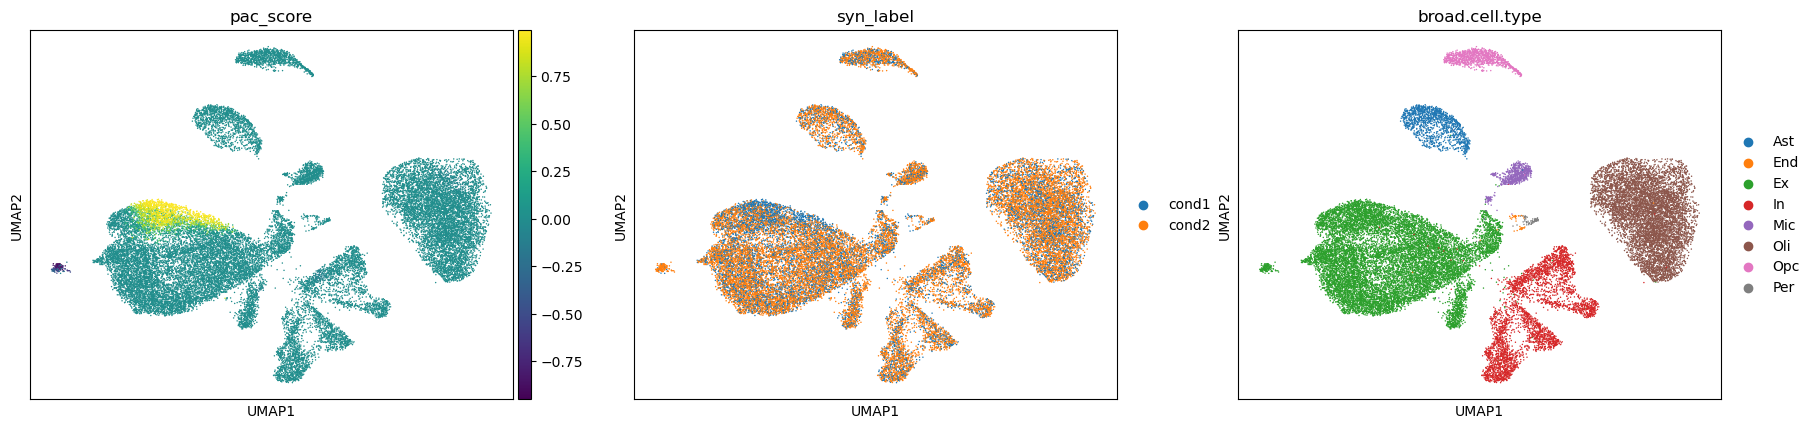

In [20]:
sc.pl.umap(adata, color=['pac_score', 'syn_label', 'broad.cell.type'])